Notebook for KPZ simulations (current)  

Note that this notebook has support for only simulations that have been saved using `.npz` + `.json` method. If you need to work with `.pkl` files, go to `ss_true_time.ipynb`. 

In [1]:
from stochastic_growth_true_time_simulation import *
from stochastic_growth_data_analysis import *
from batch_script import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
print(sys.executable)
print(sys.version)

/Users/ghan/miniconda3/envs/py313/bin/python
3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:14:06) [Clang 20.1.8 ]


# Single simulations

In this section, we go over the following:

- Initializing new simulation
- Loading simulations
- Running simulation
- (Manually) saving simulations
- Single simulation analysis

## Initialize new simulation

In [40]:
ls

[np.int64(8191)]

In [44]:
L = 2**10
mu = 4.5
seed = 5
ls = list(np.logspace(10, 10, num=1,base=2, dtype=int) )
sim = StochasticGrowthStripGeometry(L=L, mu=mu, seed=seed, initial_height=5_000)
sim.ls = ls

In [42]:
for i in range(1):
    print("hello")

hello


## Load simulation

In [3]:
save_path = "/Users/ghan/Desktop/replica_seed000002.npz"
sim = StochasticGrowthStripGeometry.load(save_path)
obs = sim.get_obs()

NameError: name 'StochasticGrowthStripGeometry' is not defined

## Running simulation

In [45]:
n_steps = int(15_488 * 1_000_000)
record_interval_true = 3
snapshot_steps = [i for i in range(0, n_steps + 1, 500_000)]
snapshot_dir = "snapshots_L16384_mu_3p6"
save_snapshots = False
obs = sim.run(
    n_steps=n_steps,
    record_interval_true=record_interval_true,
    snapshot_steps=snapshot_steps,
    snapshot_dir=snapshot_dir,
    save_snapshots=save_snapshots,
    verbose=True
)

def run_chunked(sim, n_steps, record_interval_true, chunk_steps=1_000_000):
    remaining = n_steps
    while remaining > 0:
        step = min(chunk_steps, remaining)
        sim.run(n_steps, step, record_interval_true=record_interval_true)
        print(f"Remaining {remaining/n_steps:.5f}", end='\r')
        remaining -= step

Lattice height doubled. Previous 5000. Max interface height: 3351.0.

Elapsed time: 703.697247 seconds 15488000000 --- 99.96 %



## Saving simulation

In [4]:
_L_tag = f"{sim.L}"
_mu_tag = f"{sim.mu:.2f}".replace(".", "p")
_t_tag = f"{sim.attempts // 1_000_000}M"
_seed_tag = f"{seed:06d}"

save_path = f"L{_L_tag}_mu{_mu_tag}_seed{_seed_tag}_time{_t_tag}"
sim.save(save_path)

Simulation saved to L16384_mu5p00_seed000001_time80000M.npz/.json  (t=3198.3783, accepted=50129182)


## Single simulation analysis  

For temporal plotting, the time axis will usually be of one of two things:

- $t$: This is measured by number of proliferation attempts or simulation steps. This gets updated by $dt = 1$ every step. (Computational time)
- $\tau$: The true time is related to the computational time by the following update rule: $d\tau = dt/N(t)$, where $N(t)$ is the current population number at time $t$. This relationship gaurentees that the total jump rate is always proportional to the population size. (Think: in order for the true time to change by 1 unit, we would need roughly $N$ proliferation attempts.)

### Surface heights over time

In [37]:
t[-1]

np.float64(5444.277097743602)

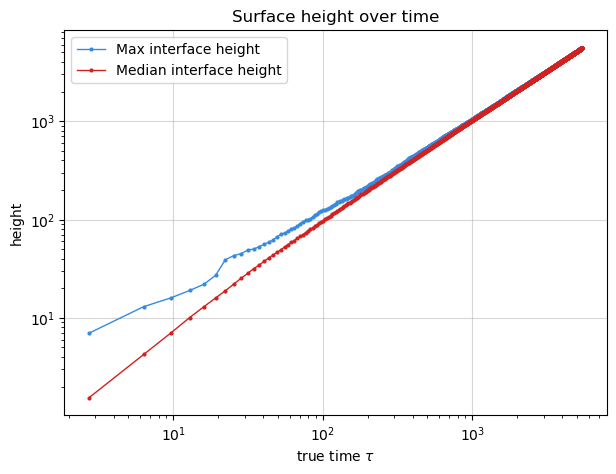

Slope of mean height: 1.020164715553964
Mean interface power: 1.0148261941332857
Max height interface power: 0.9599777990138268


In [26]:
t = obs['t']
max_height = obs['max_height_history']
mean_height = obs['mean_height_history'] 

def model(x, m):
    return m * x + 1 # we know that at time 0, the mean height is 1

popt, pcov = curve_fit(model, t, mean_height) 
m = popt[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.0, marker='o', markersize=2, label="Max interface height")
ax.plot(t, mean_height, color="#d12121", lw=1.0, marker='o', markersize=2,label="Median interface height")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel(r"true time $\tau$")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
plt.show()
print(f"Slope of mean height: {m}")
print(f"Mean interface power: {fit_loglog_slope(t, mean_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

### Plotting true time versus computational time

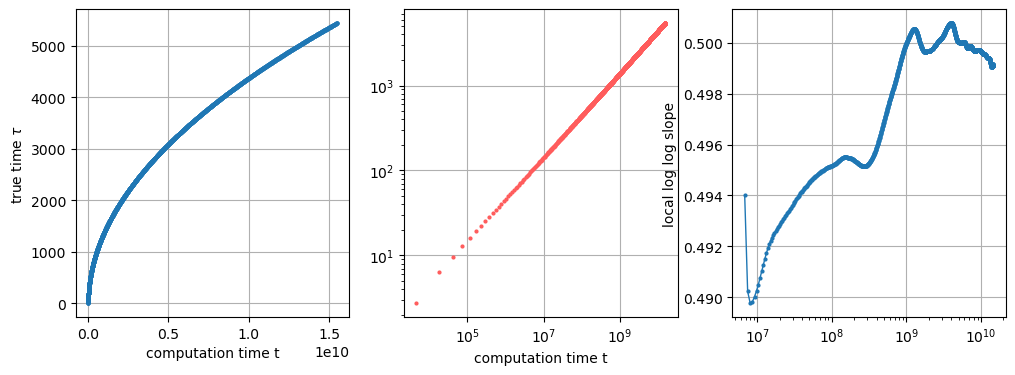

In [ ]:
t_mean = t
att = obs["t_compute"]
# print(f"Scaling of effective time versus computational time {fit_loglog_slope(att, t_mean)}")
s=100

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(att, t_mean, marker='o', markersize=2, lw=0)
ax[1].plot(att, t_mean, marker='o', markersize=2, color="#FF5C5C", lw=0)
ax[0].grid(True)
ax[1].grid(True)
ax[0].set_xlabel("computation time t")
ax[1].set_xlabel("computation time t")
ax[0].set_ylabel(r"true time $\tau$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
xs, ms = local_slopes(np.log(att), np.log(t_mean), s=s)
ax[2].plot(np.exp(xs), ms, marker='o', markersize=2, lw=1.0)
ax[2].set_xscale("log")
ax[2].set_ylabel("local log log slope")
ax[2].grid(True)
plt.show()

In [ ]:
t_mean[-1]

### Plotting population size 

slope: 1045.0573450387546
scaling 1.0086777469508037


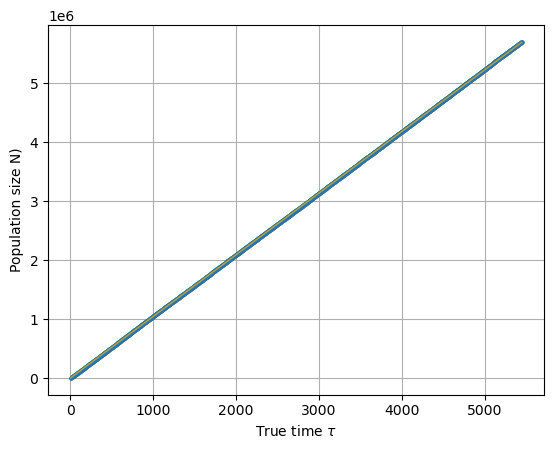

In [32]:
L = sim.L
def model(x, m):
    return m * x + L

N_t = obs["population_size"]

popt, pcov = curve_fit(model, t, N_t)
m = popt[0]

fig, ax = plt.subplots()
ax.plot(t, N_t, lw=0.0, marker='o', markersize=2)
ax.plot(t, m*t + L, lw=1, color="#D69C12")
ax.grid(True)
ax.set_ylabel(r"Population size N)")
ax.set_xlabel(r"True time $\tau$")
print(f"slope: {m}")
print(f"scaling {fit_loglog_slope(t, N_t)}")

### Spacing of samples in true time

NameError: name 'mplcursors' is not defined

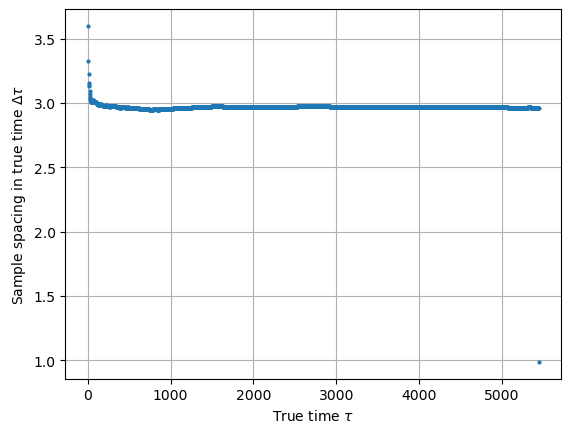

In [33]:
delta_tau = np.asarray([t[i+1]-t[i] for i in range(len(t)-1)])

fig, ax = plt.subplots()
ax.plot(t[:-1], delta_tau[:], lw=0.0, marker='o', markersize=2)
fit_loglog_slope(t[:-1], delta_tau[:])
ax.grid(True)
ax.set_xlabel(r"True time $\tau$")
ax.set_ylabel(r"Sample spacing in true time $\Delta \tau$")
mplcursors.cursor()

plt.show()

### Plotting $w(l_0, \tau)$

Generates a curve $w(l, \tau)$ for each $l$ specified in the simulation `sim.ls`.

In [36]:
obs['surface_width_history']

array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]], shape=(1834, 1))

In [34]:
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_0s = sim.ls
t = obs['t']
fig, ax = plt.subplots(figsize=(10, 7))
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    log_log_slopes.append(fit_loglog_slope(t[:], w_l_0))
    ax.plot(t[:], w_l_0, lw=0.5, label=f"$l_0$={l_0}", alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"true time $\tau$")
ax.set_ylabel("width")
ax.set_title(fr"Surface width $w(l_0, t)$, L = {sim.grid.shape[1]}, $\mu$ = {sim.mu}")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

for i, alpha in enumerate(log_log_slopes):
    print(f"l = {l_0s[i]}, alpha = {alpha}")

Mean log-log slope: nan
l = 8192, alpha = nan
Error in callback <function _draw_all_if_interactive at 0x10aa642c0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1000x700 with 1 Axes>

### Growth exponent measurement 

### Using local slopes

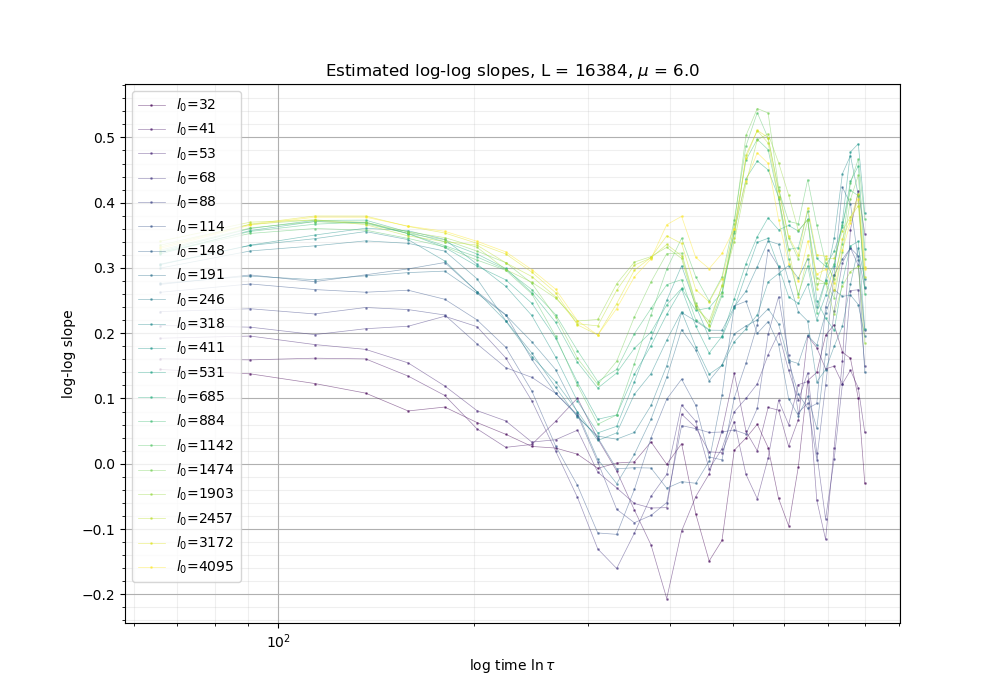

In [75]:
tlog = np.log(t)
l_0s = sim.ls
s=5

fig, ax = plt.subplots(figsize=(10, 7))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    wlog = np.log(w_l_0)
    xs, ms = local_slopes(tlog, wlog, s=s)
    ax.plot(np.exp(xs), ms, lw=0.5, label=f"$l_0$={l_0}", color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"log time $\ln \tau$")
ax.set_xscale("log")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.legend()

mplcursors.cursor(hover=True)

plt.show()

### Using secants

This is not a good idea because of transients in the surface growth.

NameError: name 'loglog_secants' is not defined

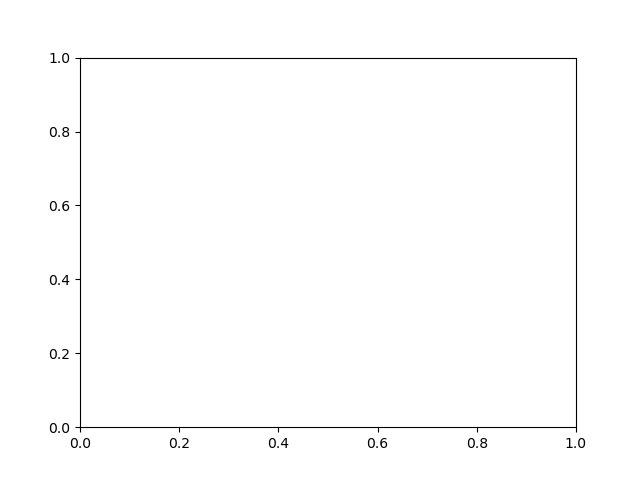

In [31]:
fig, ax = plt.subplots()
cmap_lines = plt.cm.rainbow(np.linspace(0, 1, len(ls)))

secant_start = 7

for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    xs, ms = loglog_secants(t[secant_start:], w_l_0[secant_start:])
    ax.plot(xs, ms, lw=0.5, label=f"$l_0$={l_0}",color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"log time $\ln \tau$")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.set_xscale("log")
# ax.set_xlim(-1, 2)
# ax.set_ylim(-1,2)
ax.legend()



# Parallel batch simulations

This section parallelizes multiple replicas of the same `(L, mu, ls, record intervals)` simulation across processes, each with its own seed. Each replica reuses the single-simulation machinery defined above (`StochasticGrowthStripGeometry`, its `run`, and its `save`/`load`), and replicas are written to a single ensemble directory using the same `.npz` + `.json` format as single sims.

Each replica is run in its own worker process so the numba-jitted kernels and `numpy` RNG state are independent. We use the `fork` multiprocessing context so the worker function defined in this notebook is available to the children without re-importing `__main__`.

Files are laid out as:
```
<ensemble_dir>/
    replica_seed000001.npz
    replica_seed000001.json
    replica_seed000002.npz
    ...
    ensemble_meta.json   # L, mu, n_steps, record_interval_true, ls, seeds
```

**Note** The parallel processing portion has been moved into its own script. See `simulation2_batch.py`. 

## Loading an ensemble

`batch_load` returns a `{seed: sim}` dictionary plus the ensemble metadata. Each `sim` is a fully reconstituted `StochasticGrowthStripGeometry`, so the per-replica analysis cells above (`get_obs`, surface-width plotting, growth-exponent fits, …) work on each entry unchanged.

In [5]:
ensemble_dir = r"/pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100"
replicas, ensemble_meta = batch_load(ensemble_dir)
print(f"loaded {len(replicas)} replicas from {ensemble_dir}")
print("seeds:", sorted(replicas.keys()))
print("ensemble meta:", ensemble_meta)

# Example: stack mean-height histories across replicas (they share record_interval_true,
# so the time axes are comparable but not exactly identical due to integer truncation).
obs_per_seed = {seed: sim.get_obs() for seed, sim in replicas.items()}
for seed, obs in obs_per_seed.items():
    print(f"  seed {seed:06d}: {len(obs['t'])} samples, accepted={obs['accepted']}")

Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000019.npz/.json  (t=1118.1950, accepted=16165267)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000062.npz/.json  (t=1117.8234, accepted=16176794)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000026.npz/.json  (t=1117.0141, accepted=16169105)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000024.npz/.json  (t=1117.2518, accepted=16183550)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000040.npz/.json  (t=1117.2318, accepted=16182492)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100/replica_seed000025.npz/.json  (t=1117.0746, accepted=16182981)
Simulation loaded from /pscratch/sd/g/ghan36/ensemble_L16384_mu6p00_t9000M_dtau0.05_N100

## Averaging across an ensemble

Each replica has the following histories:
- time
- widths
- max_height
- mean_height

To name a few.

Every history is aligned to its own time. Depending on acceptance rates, the true time of each record is different for different replicas. Furthermore, some replicas are ran for less time than others. We want a systematic way of aggregating the results for many many replicas.

To do this, we first align all surface width curves $w(l, \tau)$ to common time, then linearly interpolate all curves to a common grid, then average across the interpolated values.


In [10]:
# Common grid: from the latest t_start to the latest t_end
t_lo = max(obs['t'][0]  for obs in obs_per_seed.values())
t_hi = np.median([obs['t'][-1] for obs in obs_per_seed.values()])
num = max(len(obs['t']) for obs in obs_per_seed.values())
t_grid = np.linspace(t_lo, t_hi-100, num=num) # set as needed

sw_interp = []
for obs in obs_per_seed.values():
    t_r = obs['t']
    sw_r = obs['surface_width_history']  # shape (t_r, n_l)
    # interpolate each l-column onto t_grid
    cols = [np.interp(t_grid, t_r, sw_r[:, i], left=np.nan, right=np.nan) for i in range(sw_r.shape[1])]
    sw_interp.append(np.column_stack(cols))

sw_stack = np.stack(sw_interp)          # (N_replicas, n_grid, n_l)
sw_mean  = np.nanmean(sw_stack, axis=0)
# sw_std   = np.nanstd(sw_stack,  axis=0) / np.sqrt(len(sw_interp)) 
t_mean   = t_grid
ls = ensemble_meta["ls"]
L = ensemble_meta["L"]
mu = ensemble_meta["mu"]
N_ensemble = len(obs_per_seed)

## Mean surface roughness curves and $\beta$ estimation for early times

In [30]:
# WARNING DO NOT RUN THIS CELL FOR NOW
# ls = ensemble_meta["ls"]
# L = ensemble_meta["L"]
# mu = ensemble_meta["mu"]
# times = [obs['t'] for obs in obs_per_seed.values()]
# N_ensemble = len(obs_per_seed)


# t_mean = np.mean(np.vstack(times), axis=0)

# # average over surface widths
# sw = np.stack(
#     [obs['surface_width_history'] for obs in obs_per_seed.values()]
# )
# sw_mean = np.mean(sw, axis=0)
# sw_std = np.std(sw, axis=0) / np.sqrt(N_ensemble) # this is standard deviation of the mean so divide by \sqrt(n)

# local slopes method (forward window)
tlog = np.log(t_mean)
l_0s = ensemble_meta["ls"]
s=int(160*2/3) # hyper parameter controlling window size

from joblib import Parallel, delayed

def _compute_slopes(i, sw_mean_col, tlog, s):
    wlog = np.log(sw_mean_col)
    return local_slopes(tlog, wlog, s=s)

results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_compute_slopes)(i, sw_mean[:, i], tlog, s)
    for i in range(len(l_0s))
)

xs_arr, ms_arr = zip(*results)
xs_arr = list(xs_arr)
ms_arr = list(ms_arr)

## Plotting $w(l, \tau)$

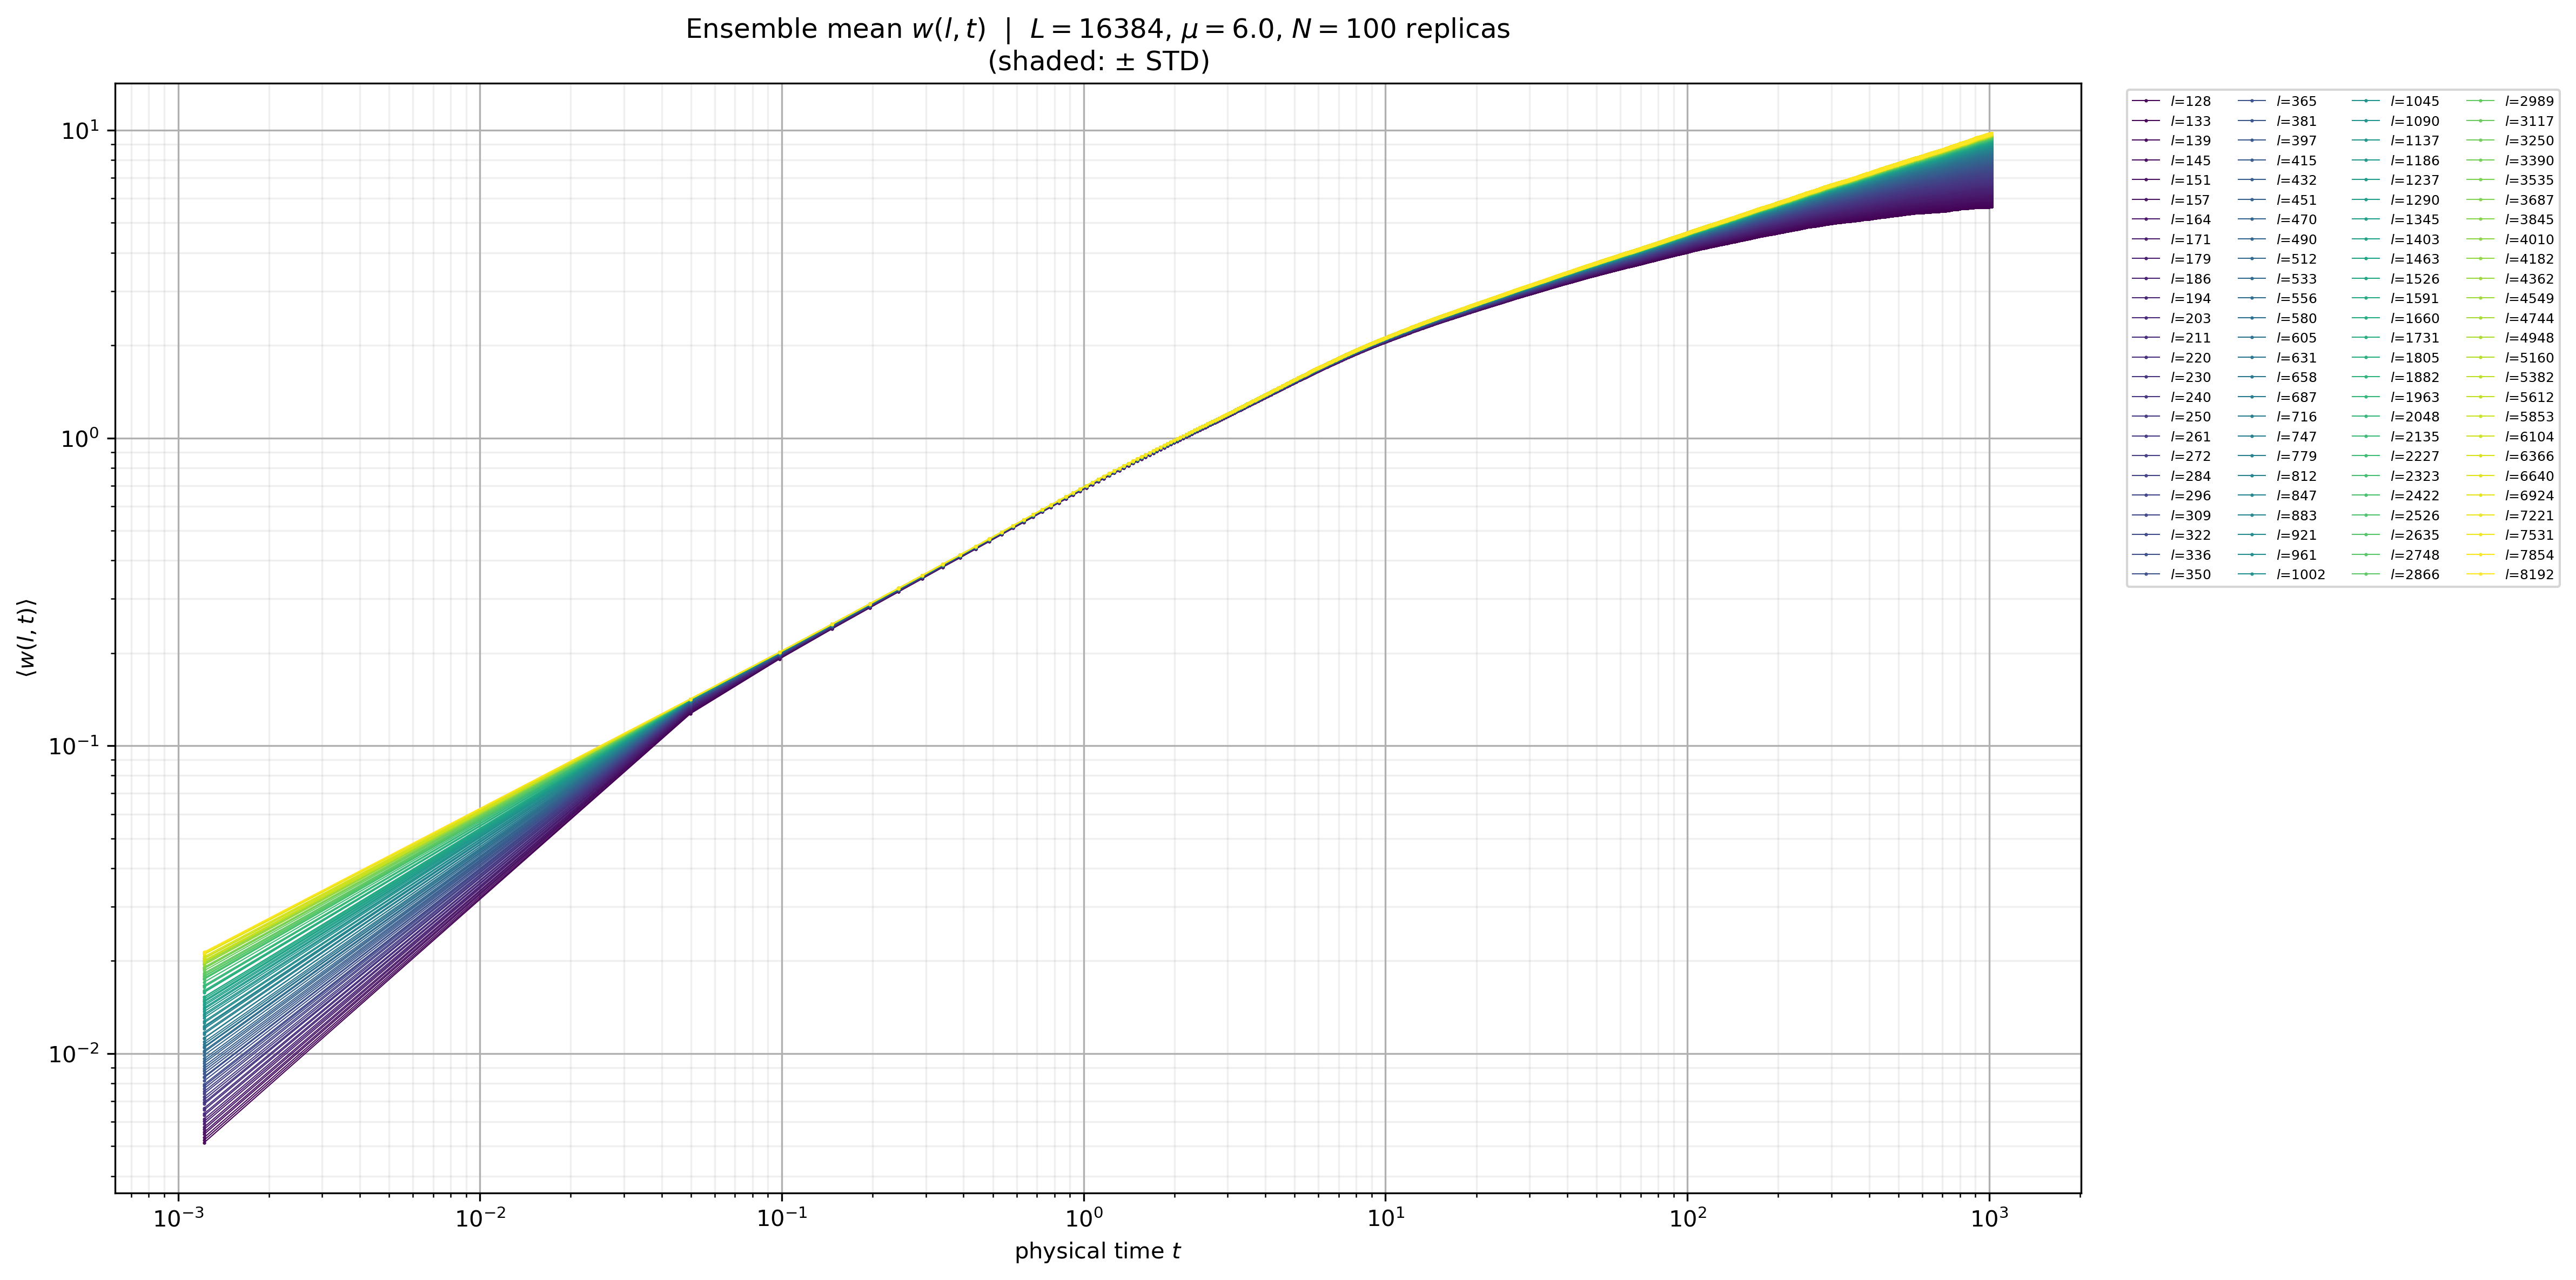

In [14]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=300)
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))

for i, l_val in enumerate(ls):
    if i == -1:
        continue
    ax.plot(t_mean, sw_mean[:, i], color=cmap_lines[i], lw=0.5, marker='o',
            markersize=0.5, label=f"$l$={l_val}")
    # ax.fill_between(
    #     t_mean,
    #     sw_mean[:, i] - sw_std[:, i],
    #     sw_mean[:, i] + sw_std[:, i],
    #     color=cmap_lines[i], alpha=0.15,
    # )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("physical time $t$")
ax.set_ylabel(r"$\langle w(l,t) \rangle$")
ax.set_title(
    rf"Ensemble mean $w(l,t)$  |  $L={L}$, $\mu={mu}$, $N={N_ensemble}$ replicas" + "\n"
    + rf"(shaded: $\pm$ STD)"
)
ax.legend(fontsize=6, ncol=4, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
plt.tight_layout()
plt.show()

In [15]:
def get_num_range(X_in, x_range = None, stride=1):
    X = X_in.copy()
    if x_range:
         mask = (X >= x_range[0]) & (X <= x_range[1])
         return len(X[mask][::stride])
    return len(X[::stride])

get_num_range(t_mean, (0.2, 8))

160

## Plotting local-slopes

/tmp/ipykernel_1457789/1611895472.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 100)


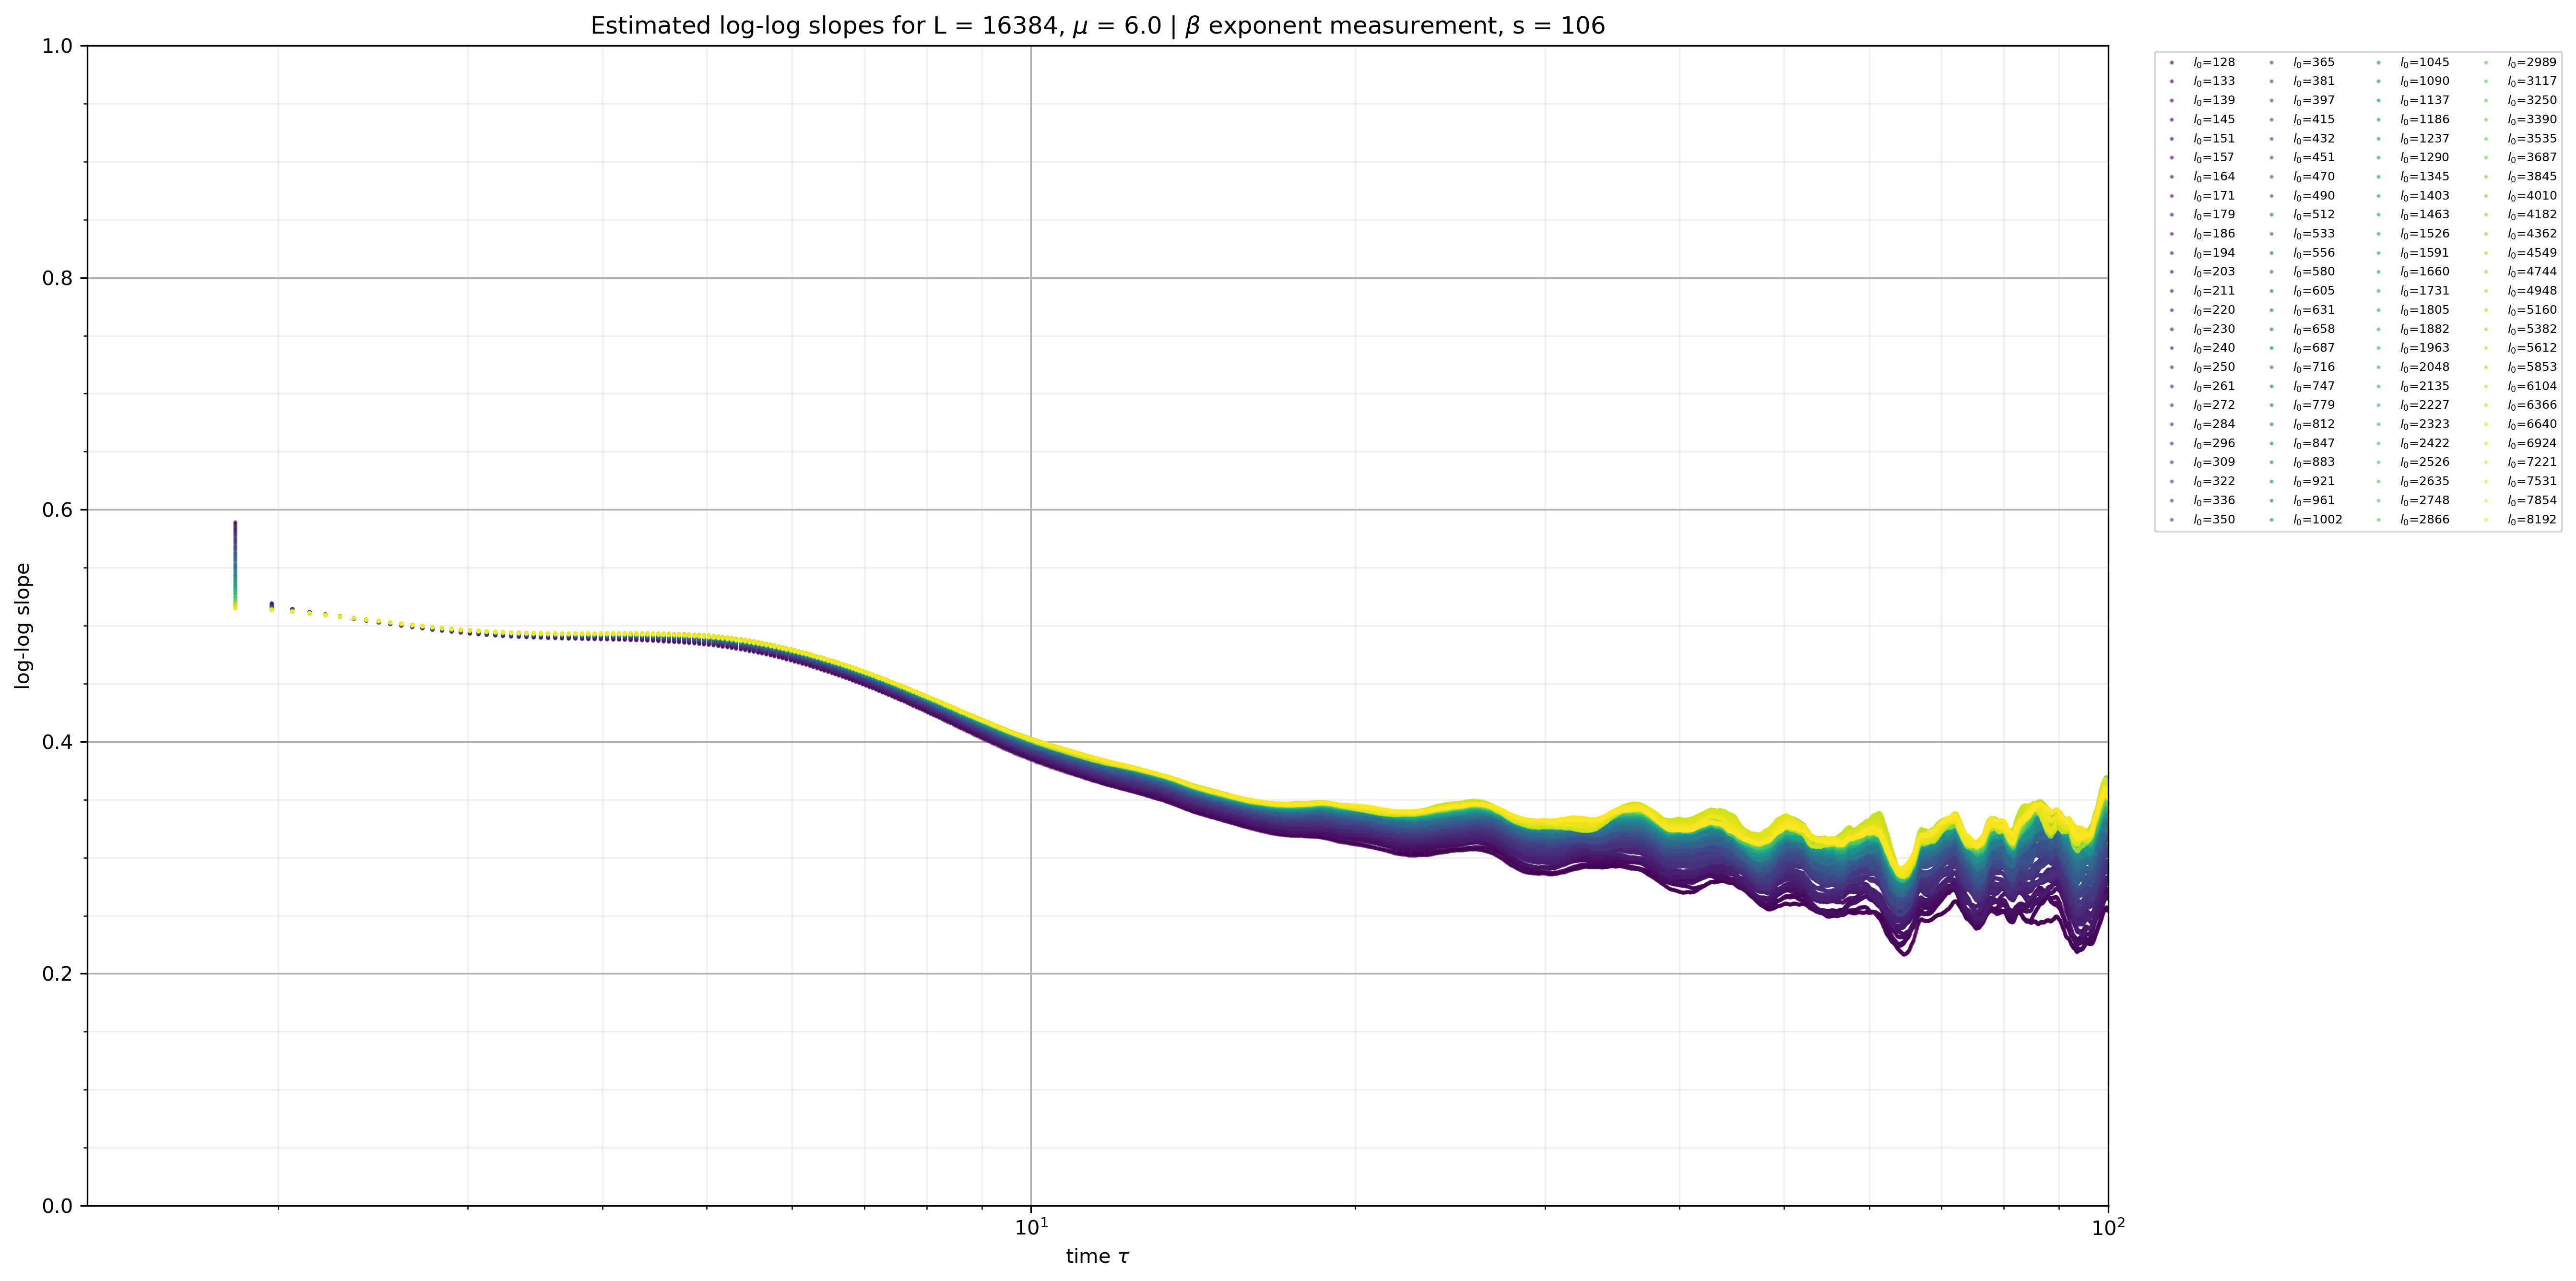

In [ ]:
fig, ax = plt.subplots(figsize=(18, 9), dpi=300)
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))
for i, l_0 in enumerate(l_0s):
    if i == 100:
        continue
    ax.plot(np.exp(xs_arr[i]), ms_arr[i], lw=0.0, label=f"$l_0$={l_0}", color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"time $\tau$")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes for L = {L}, $\mu$ = {mu} | $\beta$ exponent measurement, s = {s}")
ax.minorticks_on()
ax.set_xscale("log")
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 100)
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.legend(fontsize=6, ncol=4, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Estimating the growth exponent.

We have the following problem: we observe data $\{x, y\}$, and within some regime $x_\mathrm{min} < x < x_\mathrm{max}$ the data behaves like a powerlaw: $y = Ax^{B} + C + \eta$. How can we best estimate what the windows are and what $B$ is?

Treat this as a model selection problem, where a model $M$ is specified via $(x_\mathrm{min}, x_\mathrm{max})$. For each possible model we evaluate its [Bayesian information criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion) (BIC):
$$
BIC(M) = k\ln(n) - 2\ln(L^*)
$$
$k$ is the number of parameters in model $M$ and $L^*$ is the maximum likelihood for our model. What is our model? We make the simplest assumption:
$$
y_i \sim Ax_i^B + C + \eta, \quad \eta \sim \mathcal{N}(0, \sigma^2)
$$
And so the likelihood is as follows:
$$
L = p(\vec y \,|\, \vec \theta, \vec x, M) = \left(\frac{1}{2\pi\sigma^2} \right)^{n/2} \exp \left( - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - Ax_i^\beta - C)^2 \right)
$$
For a given $M$ we can estimate the optimal $A, B, C$ through scipy's `curve_fit`. We can then use that to solve for the optimal $\sigma^2$, which you can check is:
$$
\sigma^2 = \frac{\sum_{i=1}^n (y_i - \hat y_i)^2 }{n}
$$
Where $\hat y_i$ is the deterministic model evaluated at the optimal $A, B, C$. Plugging everything back in, we can show that the $BIC$ is:
$$
BIC(M) = k \ln(n) + n \left[\ln(2\pi) + 1 + \ln(RSS/n) \right]
$$

In [32]:
from joblib import Parallel, delayed
from stochastic_growth_data_analysis import *

l_idx = -1
l_val = ls[l_idx]
X_in = t_mean.copy()
Y_in = sw_mean[:, l_idx].copy()

def get_num_range(X_in, x_range = None, stride=1):
    X = X_in.copy()
    if x_range:
         mask = (X >= x_range[0]) & (X <= x_range[1])
         return len(X[mask][::stride])
    return None

get_num_range(X_in, x_range=(0.1, 9), stride=1)

183

In [35]:
%%time
BIC_grid, X, best = grid_search_BIC_parallel(X_in, Y_in, x_range = (0.1, 100), stride=10, n_jobs=-10)
beta = best_exponent(best, X_in, Y_in)

CPU times: user 6.14 s, sys: 576 ms, total: 6.72 s
Wall time: 6.23 s


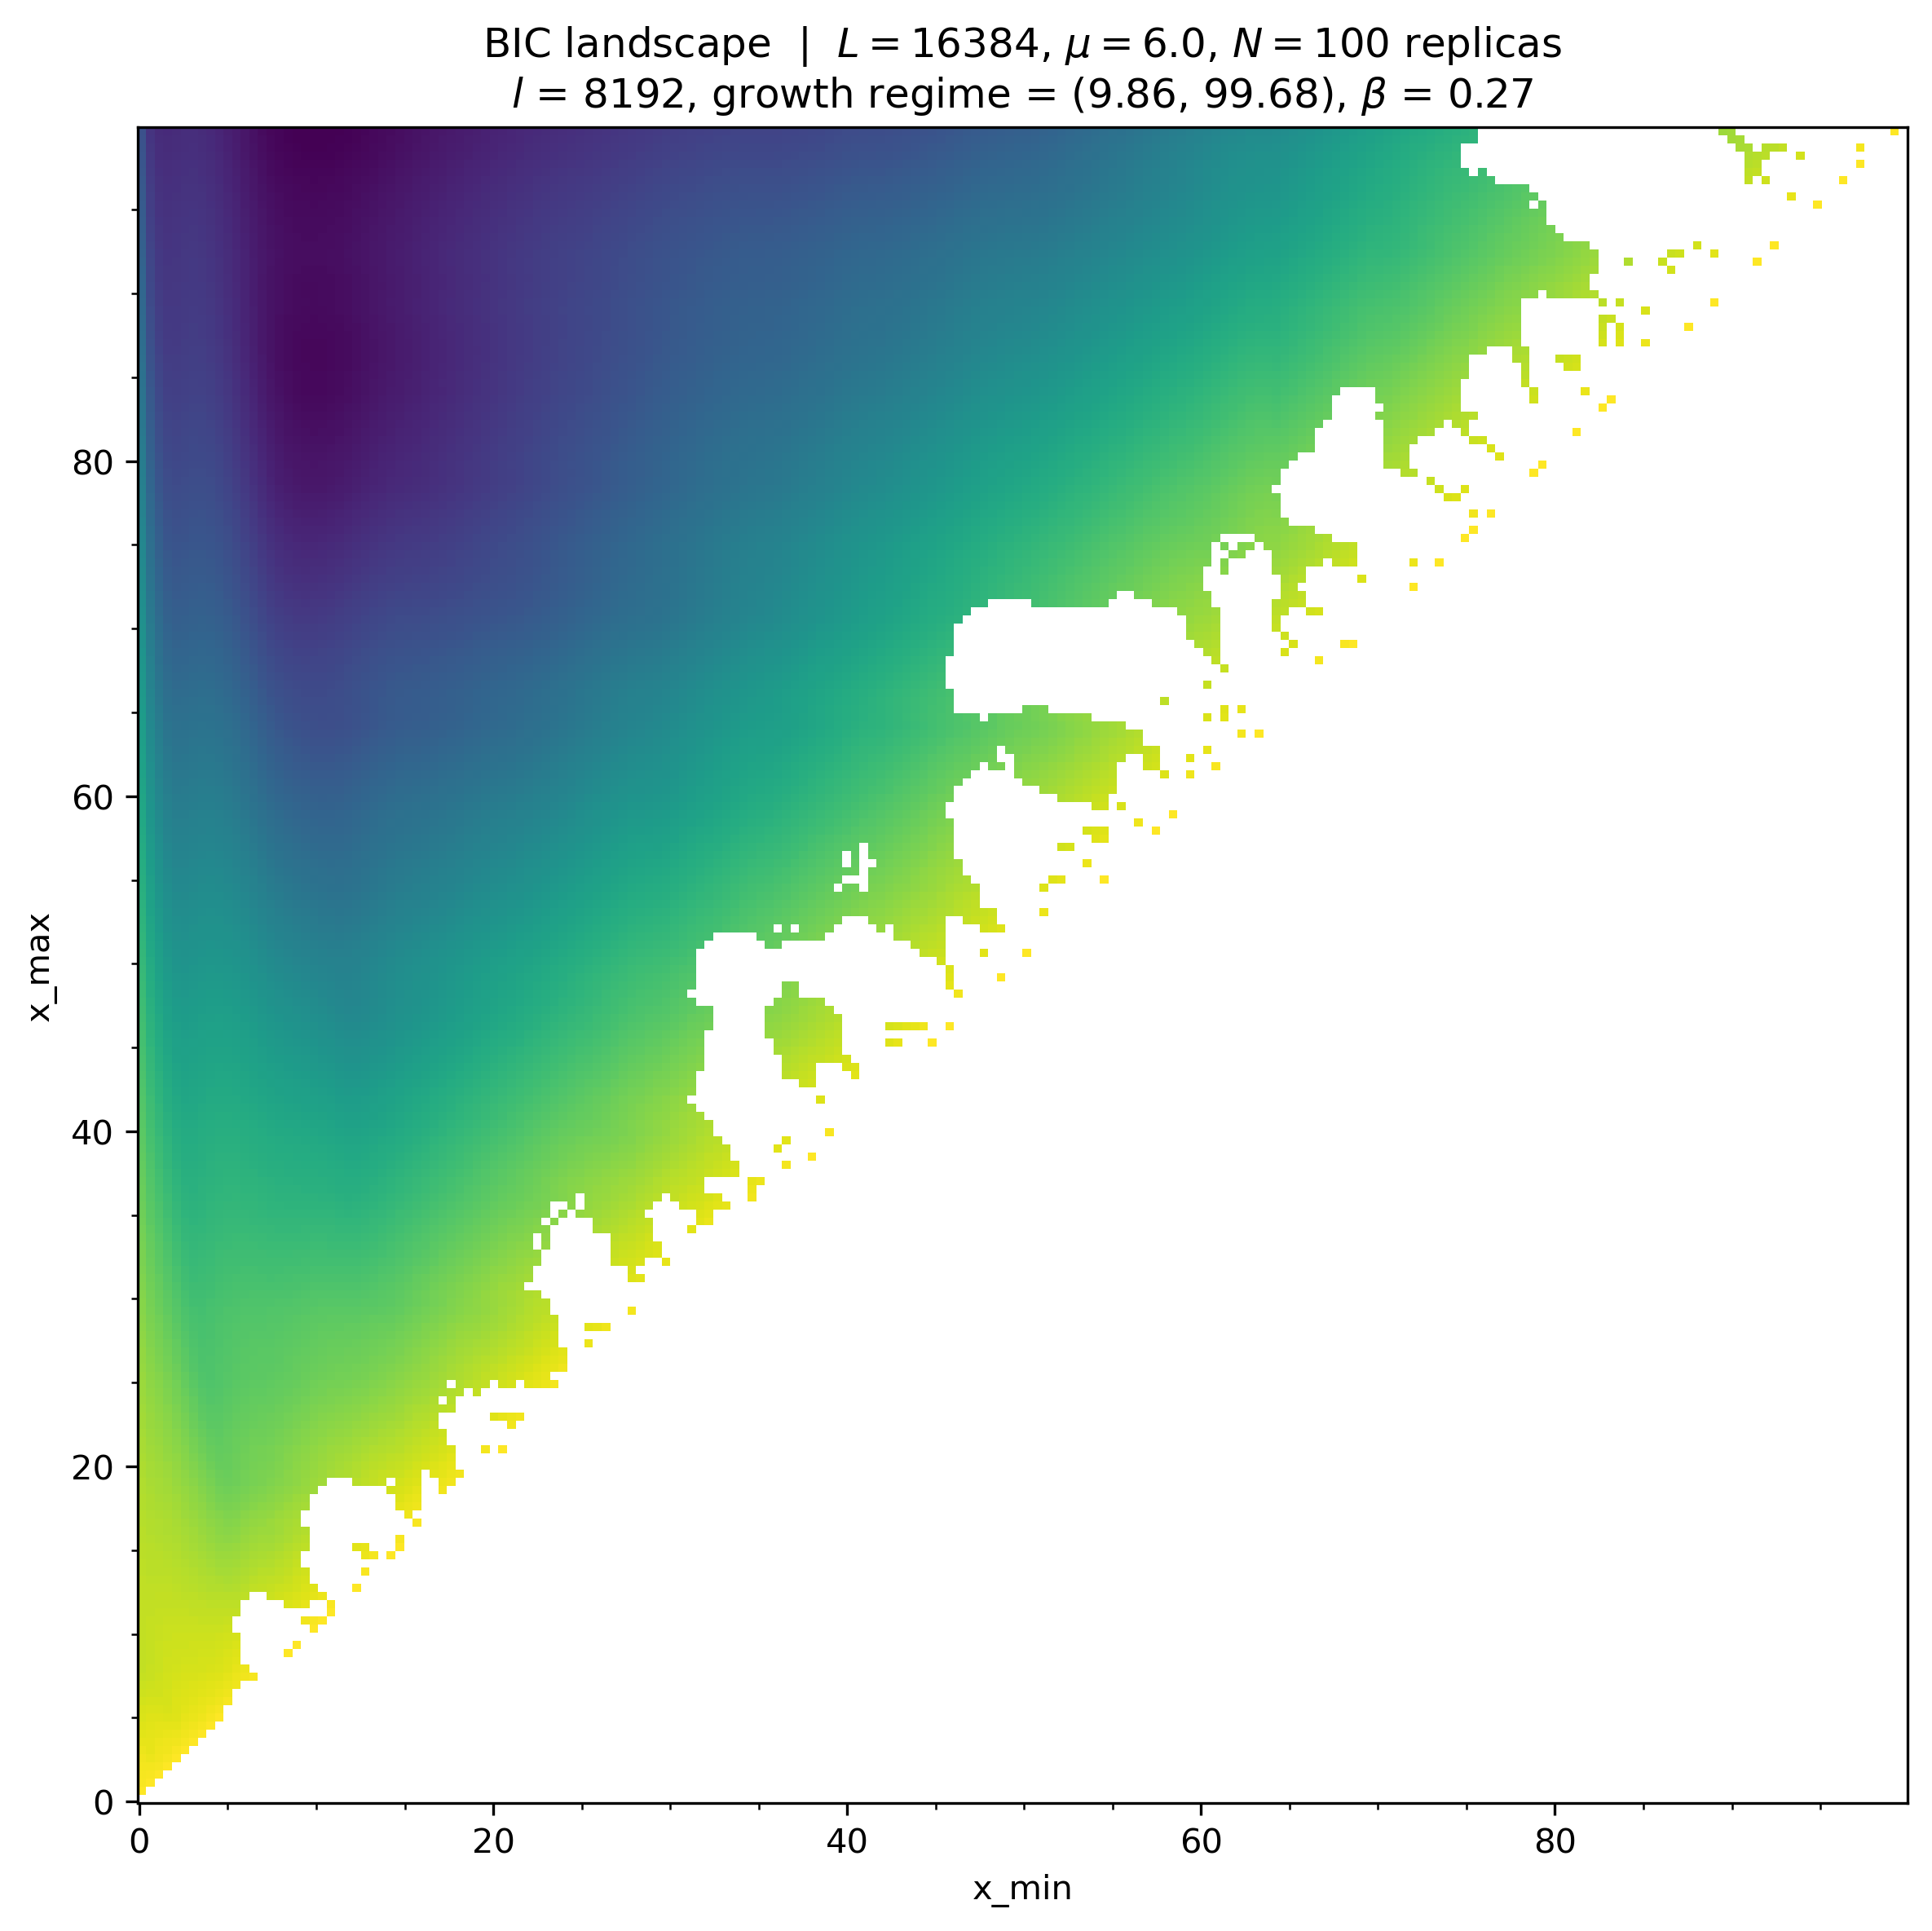

In [36]:
cfig, ax = plt.subplots(figsize=(8,8), dpi=300)
ax.pcolormesh(X, X, BIC_grid.T)
ax.set_xlabel("x_min")
ax.set_ylabel("x_max")
ax.set_title(rf"BIC landscape  |  $L={L}$, $\mu={mu}$, $N={N_ensemble}$ replicas"+"\n"
             +rf"$l$ = {l_val}, growth regime = ({best[0]:.2f}, {best[1]:.2f}), $\beta$ = {beta:.2f}")
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Estimating the roughness exponent

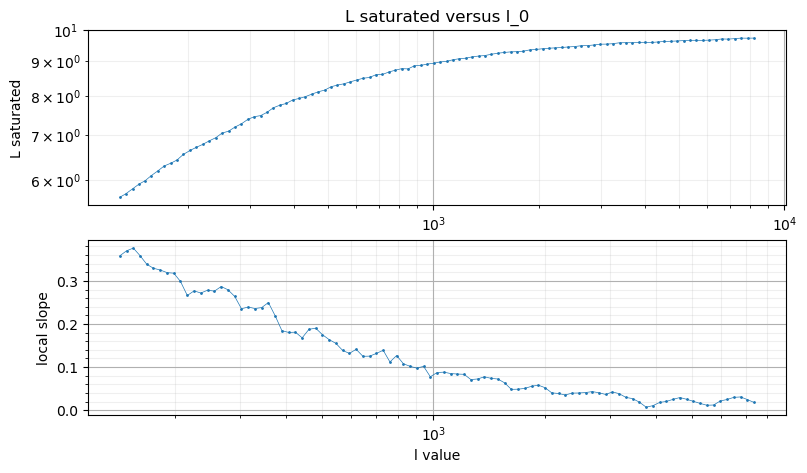

In [ ]:
ls = ensemble_meta["ls"]
L = ensemble_meta["L"]
mu = ensemble_meta["mu"]
N_ensemble = len(obs_per_seed)


L_saturate = []
last = 200

for i in range(len(ls)):
    _L_sat, _ = w_sat(sw_mean[:, i], last) 
    L_saturate.append(_L_sat)

s=10
xs, ms = local_slopes(np.log(ls), np.log(L_saturate), s=s)

fig, ax = plt.subplots(2,1,figsize=(9, 5))
ax[0].plot(ls, L_saturate, lw=0.5, marker='o', markersize=1)
#ax[0].set_xlabel(r"$l$ value")
ax[0].set_ylabel("L saturated")
ax[0].set_title(fr"L saturated versus l_0")
ax[0].minorticks_on()
ax[0].grid(True)
ax[0].grid(which='minor', alpha=0.2)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].plot(np.exp(xs), ms, lw=0.5, marker='o', markersize=1)
ax[1].set_xlabel(r"l value")
ax[1].set_ylabel(r"local slope")
ax[1].minorticks_on()
ax[1].set_xscale("log")
ax[1].grid(True)
ax[1].grid(which='minor', alpha=0.2)
plt.show()

In [11]:
def get_num_range(X_in, x_range = None, stride=1):
    X = X_in.copy()
    if x_range:
         mask = (X >= x_range[0]) & (X <= x_range[1])
         return len(X[mask][::stride])
    return len(X[::stride])

get_num_range(ls, x_range=None, stride=1)

100

Functions for determining roughness exponent $\alpha$. Now we are looking at $L_sat = L_sat(l)$. This is simpler than the last one since we can always fix the x_min = min(l) and only care about varying the top component, effectively making our model space 1-dimensional.

In [33]:
def linear_model(x, A, B):
    return A*x + B

def BIC_logspaced_1d(x_max, X=None, Y=None):
    x_min = X.min()
    if x_max <= x_min:
        return np.inf
    mask = (X >= x_min) & (X <= x_max)
    x_subset, y_subset = X[mask], Y[mask]
    n = len(x_subset)

    if n <= 3:
        return np.inf

    try:
        params, _ = curve_fit(linear_model, x_subset, y_subset, maxfev=2_000)
    except Exception:
        return np.inf

    rss = np.sum((y_subset - linear_model(x_subset, *params))**2)
    k = 2
    return k * np.log(n) + n * (np.log(2 * np.pi) + 1 + np.log(rss / n))

def grid_search_BIC_logspaced_1d_parallel(X_in, Y_in, x_range=None, stride=1, n_jobs=64):
    X = X_in.copy()
    Y = Y_in.copy()
    if x_range:
        mask = (X >= x_range[0]) & (X <= x_range[1])
        X, Y = X[mask], Y[mask]

    X_ind = X[::stride]
    N = len(X_ind)

    # Only x_max varies; x_min is fixed at X.min()
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(BIC_logspaced_1d)(X_ind[j], X=X, Y=Y)
        for j in range(N)
    )

    BIC_curve = np.array(results)
    j_best = int(np.argmin(BIC_curve))
    best = (X.min(), X_ind[j_best])
    return BIC_curve, X_ind, best

def best_slope_1d(best, X=None, Y=None):
    x_min, x_max = best
    if x_min >= x_max:
        return np.inf
    mask = (X >= x_min) & (X <= x_max)
    x_subset, y_subset = X[mask], Y[mask]
    if len(x_subset) <= 3:
        return np.inf
    try:
        params, _ = curve_fit(linear_model, x_subset, y_subset, maxfev=2_000)
    except Exception:
        return np.inf
    return params[0]

In [36]:
X_in = np.log(np.array(ls.copy()))
Y_in = np.log(np.array(L_saturate.copy()))
BIC_curve, X, best = grid_search_BIC_logspaced_1d_parallel(X_in, Y_in, x_range=None, stride=1, n_jobs=-10)
alpha = best_slope_1d(best, X_in, Y_in)

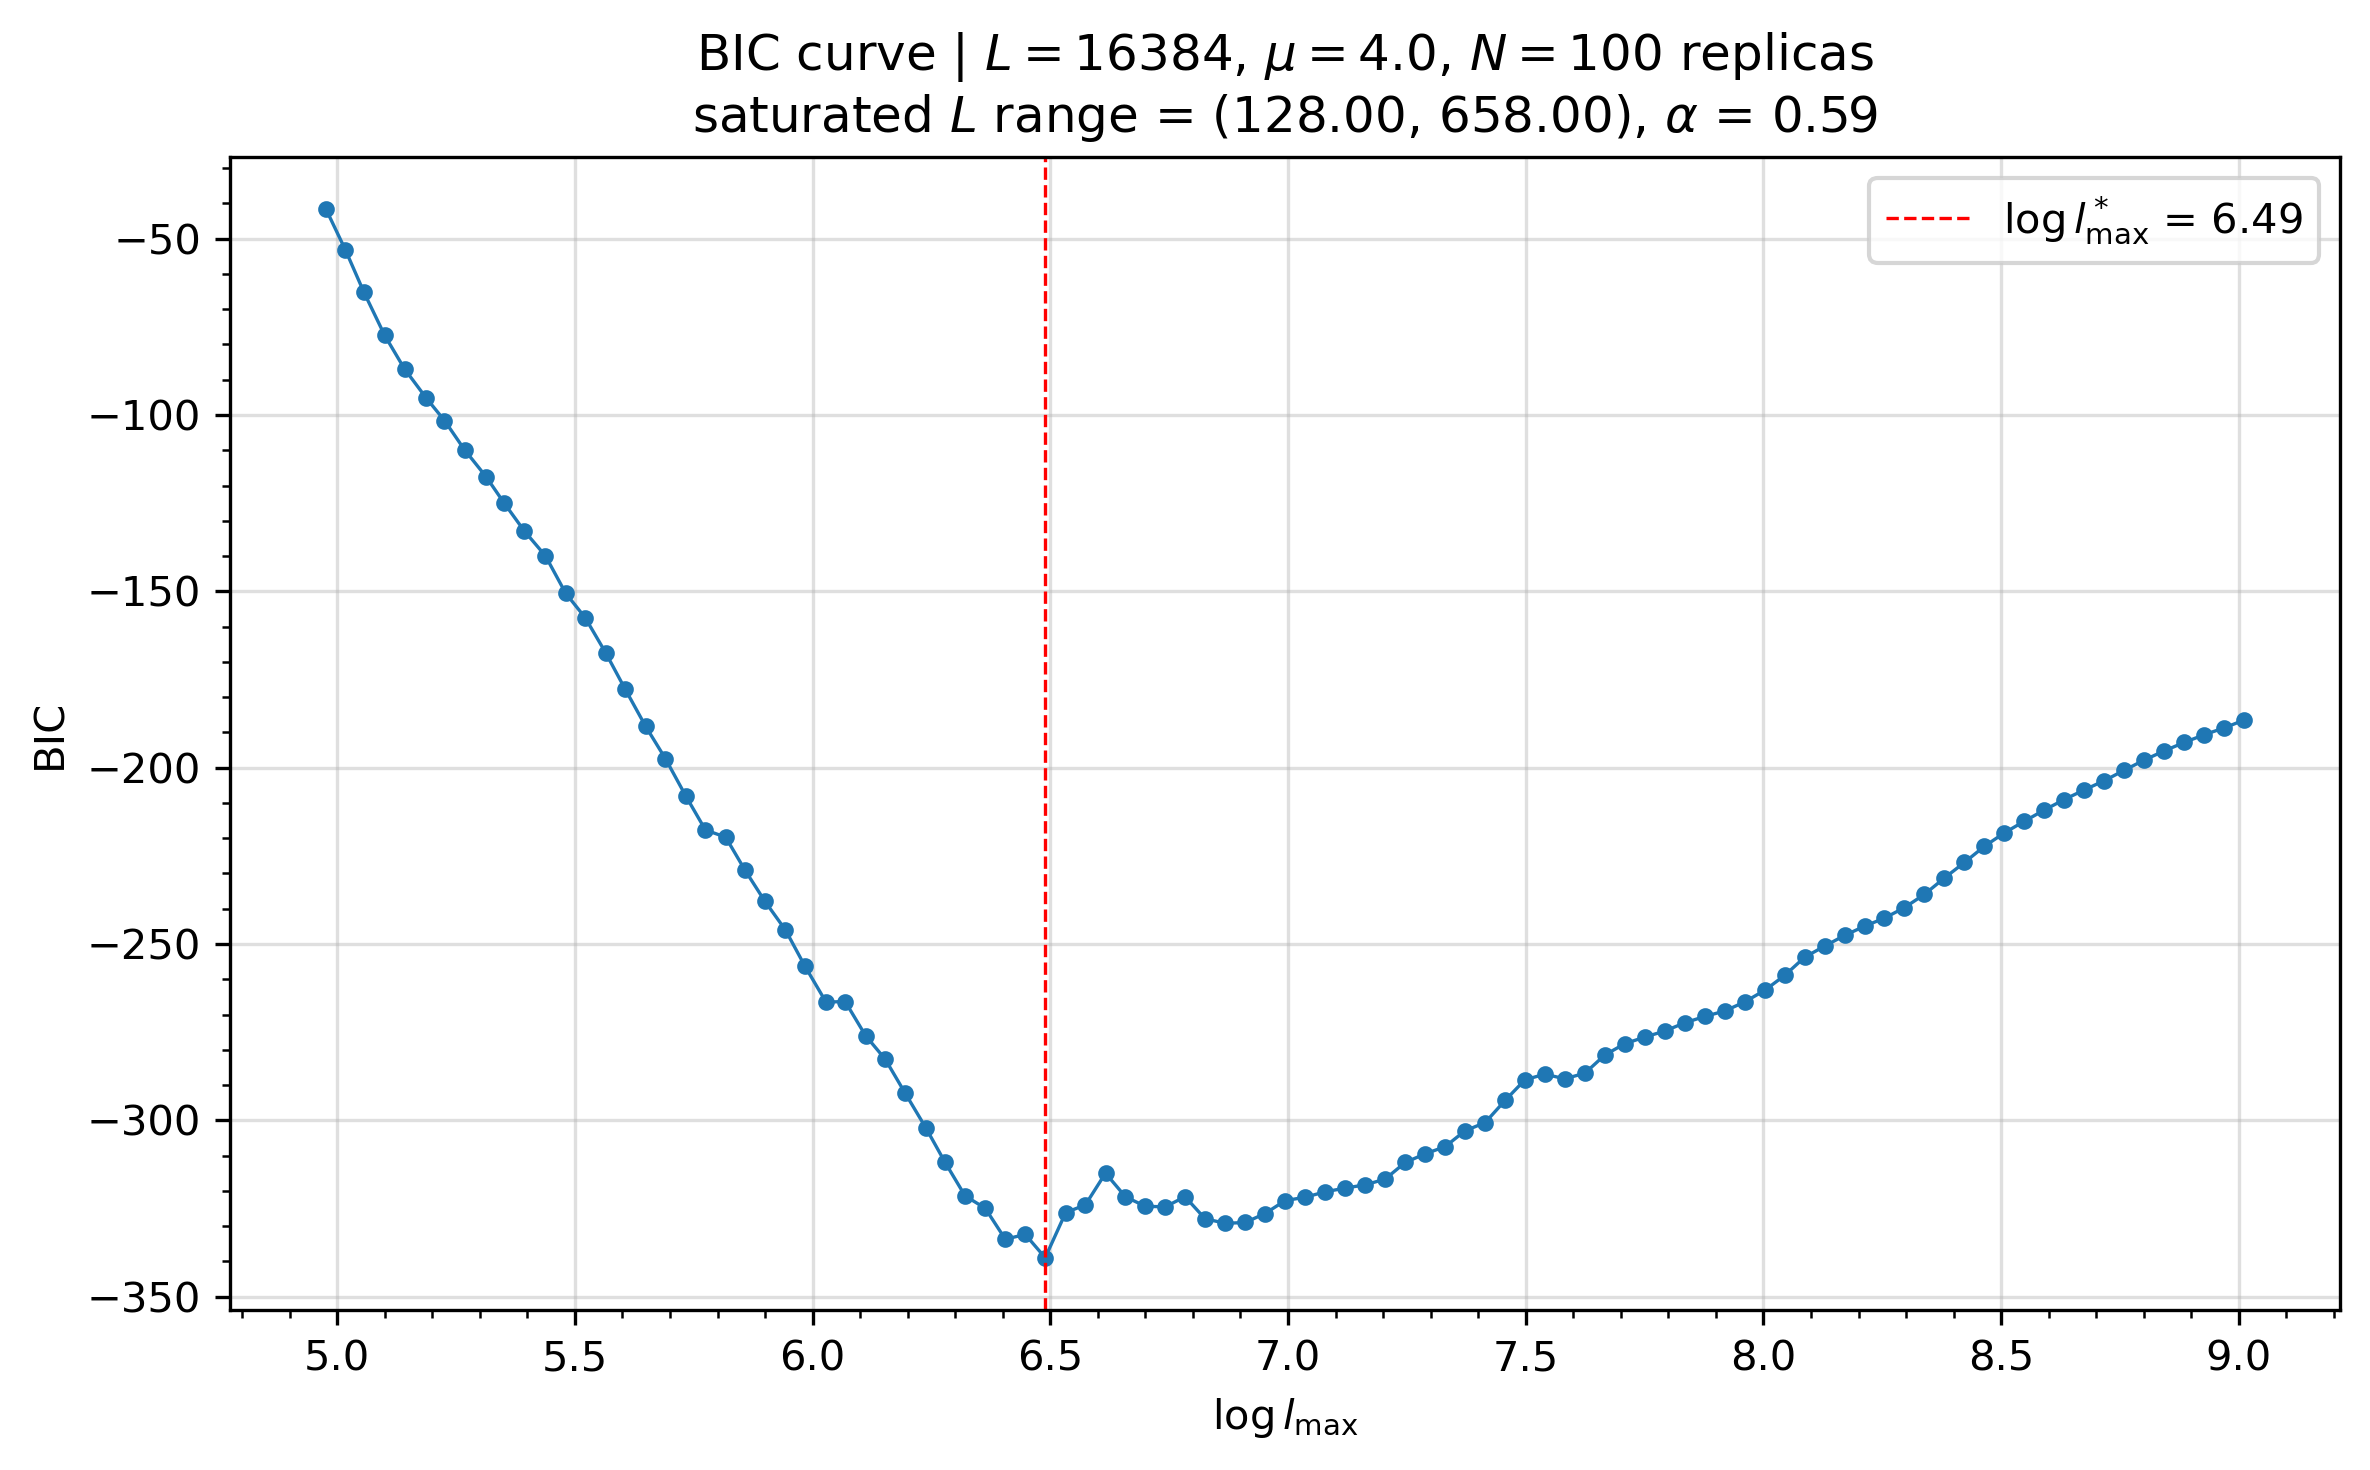

In [35]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.plot(X, BIC_curve, marker='o', markersize=3, lw=0.8)
ax.axvline(best[1], color='r', ls='--', lw=0.8, label=fr"$\log l_{{\max}}^*$ = {best[1]:.2f}")
ax.set_xlabel(r"$\log l_{\max}$")
ax.set_ylabel("BIC")
ax.set_title(
    rf"BIC curve | $L={L}$, $\mu={mu}$, $N={N_ensemble}$ replicas" + "\n"
    + rf"saturated $L$ range = ({np.exp(best[0]):.2f}, {np.exp(best[1]):.2f}), "
    + rf"$\alpha$ = {best_slope_1d(best, X_in, Y_in):.2f}"
)
ax.legend()
ax.minorticks_on()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [53]:
base_dict = {
        "L": 16384,
        "N_ensemble": 100,
        "extract_beta": False,
        "extract_alpha": True,
        "beta_x_range": (0.0, 100),     
        "beta_stride": 10,
        "beta_l_every": 5,       
        "alpha_stride": 1,
        "w_sat_last": 200,        
    }

mus = [3.50, 4.00, 4.50, 5.00, 5.50, 6.0]
t = 3_000_000
dtau = 5

ENSEMBLE = []

for mu in mus:
    temp_dict = base_dict.copy()
    temp_dict["t"] = t
    temp_dict["record_interval_true"] = dtau
    temp_dict["mu"] = mu
    ENSEMBLE.append(temp_dict)

base_dict = {
        "L": 16384,
        "N_ensemble": 100,
        "extract_beta": True,
        "extract_alpha": False,
        "beta_x_range": (0.0, 100),     
        "beta_stride": 10,
        "beta_l_every": 5,       
        "alpha_stride": 1,
        "w_sat_last": 200,        
    }

t = 9_000
dtau = 0.05

for mu in mus:
    temp_dict = base_dict.copy()
    temp_dict["t"] = t
    temp_dict["record_interval_true"] = dtau
    temp_dict["mu"] = mu
    ENSEMBLE.append(temp_dict)

In [54]:
ENSEMBLE

[{'L': 16384,
  'N_ensemble': 100,
  'extract_beta': False,
  'extract_alpha': True,
  'beta_x_range': (0.0, 100),
  'beta_stride': 10,
  'beta_l_every': 5,
  'alpha_stride': 1,
  'w_sat_last': 200,
  't': 3000000,
  'record_interval_true': 5,
  'mu': 3.5},
 {'L': 16384,
  'N_ensemble': 100,
  'extract_beta': False,
  'extract_alpha': True,
  'beta_x_range': (0.0, 100),
  'beta_stride': 10,
  'beta_l_every': 5,
  'alpha_stride': 1,
  'w_sat_last': 200,
  't': 3000000,
  'record_interval_true': 5,
  'mu': 4.0},
 {'L': 16384,
  'N_ensemble': 100,
  'extract_beta': False,
  'extract_alpha': True,
  'beta_x_range': (0.0, 100),
  'beta_stride': 10,
  'beta_l_every': 5,
  'alpha_stride': 1,
  'w_sat_last': 200,
  't': 3000000,
  'record_interval_true': 5,
  'mu': 4.5},
 {'L': 16384,
  'N_ensemble': 100,
  'extract_beta': False,
  'extract_alpha': True,
  'beta_x_range': (0.0, 100),
  'beta_stride': 10,
  'beta_l_every': 5,
  'alpha_stride': 1,
  'w_sat_last': 200,
  't': 3000000,
  'record_i